In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
# Load Data
df_original = pd.read_csv('Children Recode_final.csv')

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
df.shape

(2239, 35)

In [13]:
y_train.value_counts()

Stunting
0    1317
1     474
Name: count, dtype: int64

**Standard Scaler**

In [9]:
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

**Balancing using SMOTE**

In [35]:
# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Check new class distribution
print(y_train_sm.value_counts())

Stunting
1    1317
0    1317
Name: count, dtype: int64


*Cross-validation for best k-value*

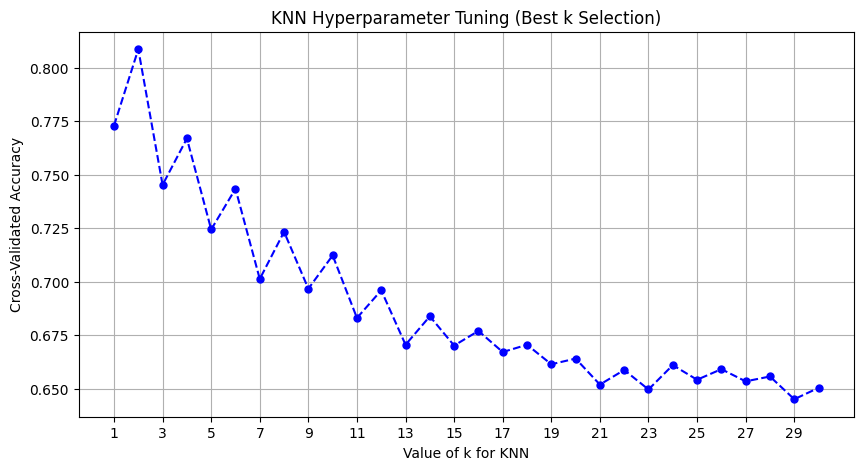

Best k after balancing: 2, Accuracy: 0.8087
Test Accuracy with best k (2): 0.6652
Confusion Matrix:
 [[264  79]
 [ 71  34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78       343
           1       0.30      0.32      0.31       105

    accuracy                           0.67       448
   macro avg       0.54      0.55      0.55       448
weighted avg       0.67      0.67      0.67       448



In [38]:
k_values = range(1, 31)
cv_scores = []

# Perform cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sm, y_train_sm, cv=10, scoring='accuracy')  # Cross-validation on SMOTE-balanced data
    cv_scores.append(scores.mean())

# Plot accuracy vs. k values
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='b', markersize=5)
plt.xlabel('Value of k for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Hyperparameter Tuning (Best k Selection)')
plt.xticks(range(1, 31, 2))
plt.grid(True)
plt.show()

# Best k selection
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

# Train final model with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sm, y_train_sm)

# Evaluate on the original test set (which was never oversampled)
test_accuracy = knn_best.score(X_test_scaled, y_test)
print(f"Test Accuracy with best k ({best_k}): {test_accuracy:.4f}")

# Predictions
predictions_scaled = knn_best.predict(X_test_scaled)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions_scaled)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
print("Classification Report:\n", classification_report(y_test, predictions_scaled))

In [ ]:
#  # Finding the best k using cross-validation
# X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(X_sm, y_sm, 
#                                 test_size=0.20, stratify=y_sm, random_state=42)

# k_values = range(1, 31)
# cv_scores = []

# # Peform cross-validation for each k
# for k in k_values:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     scores = cross_val_score(knn, X_train_balanced, y_train_balanced, cv = 10, scoring = 'accuracy') 
#     cv_scores.append(scores.mean())

# # Plot accuracy vs. k values
# plt.figure(figsize=(10, 5))
# plt.plot(k_values, cv_scores, marker='o', linestyle='--')
# plt.xlabel('Value of k for KNN')
# plt.ylabel('Test Set Accuracy')
# plt.title('Test Accuracy for Different k Values')
# plt.grid(True)
# plt.show()

# # Best k selection
# best_k = k_values[np.argmax(cv_scores)]
# print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

In [ ]:
# # Train the best model with balanced data
# knn_best = KNeighborsClassifier(n_neighbors=best_k)
# knn_best.fit(X_train_balanced, y_train_balanced)

# # Test accuracy
# test_accuracy = knn_best.score(X_test_balanced, y_test_balanced)
# print(f"Test Accuracy with best k ({best_k}): {test_accuracy:.4f}")

# # Cofusion Matrix
# predictions_scaled = knn_best.predict(X_test_balanced)
# confusion_matrix(y_test_balanced, predictions_scaled)

Test Accuracy with best k (2): 0.7799


array([[191,  73],
       [ 43, 220]])

In [ ]:
# knn_best = KNeighborsClassifier(n_neighbors=2)
# knn_best.fit(X_train_balanced, y_train_balanced)

# # Predictions
# y_pred = knn_best.predict(X_test_balanced)

# # Classification Report
# print(classification_report(y_test_balanced, y_pred))

# # ROC-AUC Score
# auc = roc_auc_score(y_test_balanced, knn_best.predict_proba(X_test_balanced)[:,1])
# print(f"ROC-AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.82      0.72      0.77       264
           1       0.75      0.84      0.79       263

    accuracy                           0.78       527
   macro avg       0.78      0.78      0.78       527
weighted avg       0.78      0.78      0.78       527

ROC-AUC Score: 0.7992
